In [2]:
#libraried
import pandas as pd

In [3]:
#read the dataset
train_data = pd.read_csv('./dataset/train.csv')
test_data = pd.read_csv('./dataset/test.csv')

In [4]:
train_data.shape, test_data.shape

((4459, 4993), (49342, 4992))

In [5]:
train_data.head()

,ID,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,000d6aaf2,38000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,000fbd867,600000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0027d6b71,10000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0028cbf45,2000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,002a68644,14400000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [6]:
train_data['target'].describe()

count    4.459000e+03
mean     5.944923e+06
std      8.234312e+06
min      3.000000e+04
25%      6.000000e+05
50%      2.260000e+06
75%      8.000000e+06
max      4.000000e+07
Name: target, dtype: float64

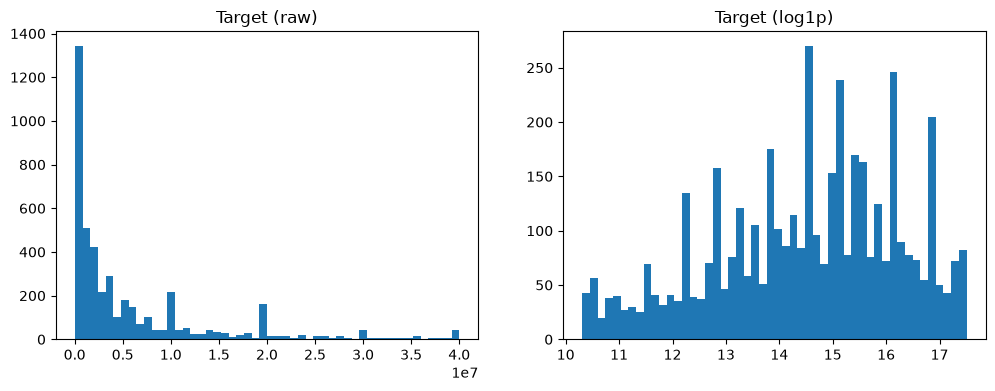

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_data['target'], bins=50)
axes[0].set_title('Target (raw)')

import numpy as np
axes[1].hist(np.log1p(train_data['target']), bins=50)
axes[1].set_title('Target (log1p)')

plt.show()

Where we are: target skewed → log1p fixes it. p >> n (4991 features, 4459 rows) → overfitting risk, need regularization/dimensionality reduction. Test set 10x bigger than train → suspicious, revisit in step 4.

In [8]:
# % of values that are zero, overall
zero_pct = (train_data.drop(['ID','target'], axis=1) == 0).mean().mean()
print(zero_pct)

# constant columns (zero variance = useless)
const_cols = [c for c in train_data.columns if train_data[c].nunique() == 1]
print(len(const_cols))

# duplicate columns
print(train_data.drop(['ID','target'], axis=1).T.duplicated().sum())

0.9685413111171313
256
260


Quick recap of where we stand:

Target: skewed → log1p it
p >> n (4991 features, 4459 rows) → overfitting risk → need regularization/dim-reduction
Test is 10x bigger than train → suspicious, revisit later
96.85% zeros, 256 constant cols, 260 duplicate cols → drop the dead columns, lean into sparsity

Next step — cleanup + one more anomaly check.

In [9]:
print('before cleaning up: ', train_data.shape)
train_clean = train_data.drop(columns=const_cols)
dup_cols = train_clean.drop(['ID','target'], axis=1).T[train_clean.drop(['ID','target'], axis=1).T.duplicated()].index
train_clean = train_clean.drop(columns=dup_cols)
print('after cleaning up: ', train_clean.shape)

before cleaning up:  (4459, 4993)
after cleaning up:  (4459, 4732)


In [10]:
#we have to check whether there are duplicate rows in the dataset or not
print(train_clean.drop(['ID','target'], axis=1).duplicated().sum())

1


we'll get to the leacking part later and now we move to the step 5 which is baseline. 

In [11]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

y = np.log1p(train_clean['target'])
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []
for train_idx, val_idx in kf.split(y):
    pred = np.full(len(val_idx), y.iloc[train_idx].mean())  # predict mean every time
    rmsle = np.sqrt(mean_squared_error(y.iloc[val_idx], pred))
    scores.append(rmsle)

print(np.mean(scores))

1.7505728979239337


dumb baseline → simple model on raw features (isolate FE's contribution) → feature engineering → re-run model, compare → model tuning/selection.

Given p >> n and heavy sparsity, I'll go with LightGBM because tree-based models naturally ignore irrelevant/zero-heavy features better than linear models

In [12]:
import lightgbm as lgb

X = train_clean.drop(['ID', 'target'], axis=1)
y = np.log1p(train_clean['target'])

scores = []
for train_idx, val_idx in kf.split(X):
    model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
    model.fit(X.iloc[train_idx], y.iloc[train_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = model.predict(X.iloc[val_idx])
    rmsle = np.sqrt(mean_squared_error(y.iloc[val_idx], pred))
    scores.append(rmsle)

print(np.mean(scores))

/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132354
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3301
[LightGBM] [Info] Start training from score 14.490748


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131707
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3288
[LightGBM] [Info] Start training from score 14.500282


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131683
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3325
[LightGBM] [Info] Start training from score 14.490588


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 132160
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3307
[LightGBM] [Info] Start training from score 14.475555


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131057
[LightGBM] [Info] Number of data points in the train set: 3568, number of used features: 3292
[LightGBM] [Info] Start training from score 14.494022
1.4380696079807642


Step 6: Feature Engineering

In [13]:
def add_row_stats(df):
    X = df.drop(['ID', 'target'], axis=1, errors='ignore')
    stats = pd.DataFrame(index=df.index)
    stats['nonzero_count'] = (X != 0).sum(axis=1)
    stats['sum'] = X.sum(axis=1)
    stats['mean'] = X.mean(axis=1)
    stats['std'] = X.std(axis=1)
    stats['max'] = X.max(axis=1)
    stats['min'] = X.min(axis=1)
    stats['median'] = X.median(axis=1)
    return stats

row_stats = add_row_stats(train_clean)
X_new = pd.concat([train_clean.drop(['ID','target'], axis=1), row_stats], axis=1)

In [14]:
scores = []
for train_idx, val_idx in kf.split(X_new):
    model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
    model.fit(X_new.iloc[train_idx], y.iloc[train_idx],
              eval_set=[(X_new.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = model.predict(X_new.iloc[val_idx])
    rmse = np.sqrt(mean_squared_error(y.iloc[val_idx], pred))
    scores.append(rmse)

print(np.mean(scores))

/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 133606
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3306
[LightGBM] [Info] Start training from score 14.490748


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132960
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3293
[LightGBM] [Info] Start training from score 14.500282


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 132931
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3330
[LightGBM] [Info] Start training from score 14.490588


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133409
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3312
[LightGBM] [Info] Start training from score 14.475555


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132310
[LightGBM] [Info] Number of data points in the train set: 3568, number of used features: 3297
[LightGBM] [Info] Start training from score 14.494022
1.389255223537233


Dimontionality Reduction

In [15]:
from sklearn.decomposition import TruncatedSVD

X_raw = train_clean.drop(['ID','target'], axis=1)
svd = TruncatedSVD(n_components=50, random_state=42)
svd_feats = svd.fit_transform(X_raw)
svd_df = pd.DataFrame(svd_feats, columns=[f'svd_{i}' for i in range(50)], index=X_raw.index)

X_final = pd.concat([X_new, svd_df], axis=1)

In [16]:
scores = []
for train_idx, val_idx in kf.split(X_final):
    model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
    model.fit(X_final.iloc[train_idx], y.iloc[train_idx],
              eval_set=[(X_final.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = model.predict(X_final.iloc[val_idx])
    rmse = np.sqrt(mean_squared_error(y.iloc[val_idx], pred))
    scores.append(rmse)

print(np.mean(scores))

/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 146356
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3356
[LightGBM] [Info] Start training from score 14.490748


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 145710
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3343
[LightGBM] [Info] Start training from score 14.500282


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 145681
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3380
[LightGBM] [Info] Start training from score 14.490588


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 146159
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3362
[LightGBM] [Info] Start training from score 14.475555


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 145060
[LightGBM] [Info] Number of data points in the train set: 3568, number of used features: 3347
[LightGBM] [Info] Start training from score 14.494022
1.3848992707294658


Where you stand: dumb baseline 1.75 → raw LightGBM 1.438 → +row-stats 1.389 → +SVD 1.385.

Now we do hyperparameter tuning

In [17]:
import lightgbm as lgb
import numpy as np

param_grid = {
    'num_leaves': [15, 31, 63],
    'max_depth': [4, 6, -1],
    'min_child_samples': [10, 20, 40],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1],
}

import random
random.seed(42)
best_score = 999
best_params = None

for i in range(10):  # 10 random combos, cheap enough to run
    params = {k: random.choice(v) for k, v in param_grid.items()}
    fold_scores = []
    for train_idx, val_idx in kf.split(X_final):
        model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42, verbose=-1, **params)
        model.fit(X_final.iloc[train_idx], y.iloc[train_idx],
                  eval_set=[(X_final.iloc[val_idx], y.iloc[val_idx])],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        pred = model.predict(X_final.iloc[val_idx])
        fold_scores.append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
    avg = np.mean(fold_scores)
    print(params, avg)
    if avg < best_score:
        best_score = avg
        best_params = params

print("BEST:", best_params, best_score)

/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm

{'num_leaves': 63, 'max_depth': 4, 'min_child_samples': 10, 'reg_alpha': 1, 'reg_lambda': 0.1} 1.3917021788563466


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm

{'num_leaves': 15, 'max_depth': 4, 'min_child_samples': 10, 'reg_alpha': 1, 'reg_lambda': 0} 1.3918294524070958


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm

...

{'num_leaves': 15, 'max_depth': 4, 'min_child_samples': 40, 'reg_alpha': 0.1, 'reg_lambda': 0.1} 1.3896639155176282


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm

{'num_leaves': 31, 'max_depth': 4, 'min_child_samples': 10, 'reg_alpha': 0.1, 'reg_lambda': 0} 1.3935459261346164


/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/lightgbm

{'num_leaves': 15, 'max_depth': 6, 'min_child_samples': 10, 'reg_alpha': 0.1, 'reg_lambda': 0.1} 1.3893937318681295
BEST: {'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 40, 'reg_alpha': 0, 'reg_lambda': 1} 1.3831683685828842


Recap of the full trajectory:

- Dumb baseline: 1.750
- Raw LightGBM: 1.438
- row stats: 1.389
- SVD: 1.385
- tuning: 1.383

### test.csv must go through the exact same preprocessing as train

In [18]:

# apply same column drops as train
test_clean = test_data.drop(columns=[c for c in const_cols if c in test_data.columns])
test_clean = test_clean.drop(columns=[c for c in dup_cols if c in test_clean.columns])

# same row stats
test_row_stats = add_row_stats(test_clean)
X_test = pd.concat([test_clean.drop(['ID'], axis=1), test_row_stats], axis=1)

# same SVD transform (reuse the FITTED svd from train, don't refit!)
test_svd_feats = svd.transform(test_clean.drop(['ID'], axis=1))
test_svd_df = pd.DataFrame(test_svd_feats, columns=[f'svd_{i}' for i in range(50)], index=X_test.index)

X_test_final = pd.concat([X_test, test_svd_df], axis=1)

# train final model on ALL train data (not folds), using best tuned params
final_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42, verbose=-1,
                                  num_leaves=63, max_depth=-1, min_child_samples=40, reg_alpha=0, reg_lambda=1)
final_model.fit(X_final, y)

test_preds_log = final_model.predict(X_test_final)
test_preds = np.expm1(test_preds_log)  # reverse the log1p transform

submission = pd.DataFrame({'ID': test_data['ID'], 'target': test_preds})
submission.to_csv('submission.csv', index=False)